# FUSE Metric Implementation for AI Image Detection

This notebook implements the **FUSE (Fusion of Unnatural Spectral & Entropy)** metric.
It is designed to distinguishing **Real vs. AI-Generated Images** (e.g., from Stable Diffusion, Midjourney) by analyzing specific artifacts:
1.  **Spectral Artifacts**: High-frequency anomalies in the Fourier domain.
2.  **Entropy Anomalies**: Unnatural uniformity or variance in local information density.

**Dataset**: Designed for datasets like **GenImage**.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import entropy
from skimage.measure import shannon_entropy
from skimage.filters.rank import entropy as local_entropy
from skimage.morphology import disk
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score

# Configuration
# Use absolute path to avoid ambiguity about where the dataset is created
BASE_DIR = os.getcwd()
DATASET_PATH = os.path.join(BASE_DIR, "dataset_fuse_demo", "GenImage") 
REAL_FOLDER = "Real"
FAKE_FOLDER = "Fake"

print(f"Working Directory: {BASE_DIR}")
print(f"Target Dataset Path: {DATASET_PATH}")

# Ensure visualization works in notebook
%matplotlib inline

## 2. Define FUSEMetric Class

The core logic is encapsulated here.
*   **Spectral Score**: Calculates energy in high frequencies.
*   **Entropy Score**: Calculates variance of local entropy map.
*   **Fusion**: weighted combination.

In [2]:
class FUSEMetric:
    def __init__(self, high_freq_threshold=0.75, patch_size=4):
        """
        Args:
            high_freq_threshold (float): Ratio of radius to cut off low frequencies (0.0 to 1.0).
            patch_size (int): Radius for local entropy disk calculation.
        """
        self.high_freq_threshold = high_freq_threshold
        self.patch_size = patch_size
        
        # Weighing factors (can be tuned via Logistic Regression later)
        # Assuming AI images have HIGH spectral energy and LOW entropy variance
        self.alpha_spectral = 0.5 
        self.beta_entropy = 0.5       

    def _compute_spectral_score(self, img_gray):
        """
        Computes high-frequency energy ratio in Log-Magnitude Spectrum.
        AI images often have grid-like artifacts -> higher HF energy.
        """
        f = np.fft.fft2(img_gray)
        fshift = np.fft.fftshift(f)
        magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)
        
        rows, cols = img_gray.shape
        crow, ccol = rows // 2, cols // 2
        
        # Create High Pass Filter (Circular Mask)
        # We want to measure energy OUTSIDE the center circle
        mask = np.ones((rows, cols), np.uint8)
        r = int(min(rows, cols) * 0.5 * (1 - self.high_freq_threshold)) # radius of low freq to ignore
        # Note: high_freq_threshold > 0.75 means we check outer 25%? 
        # Let's adjust logic: high_freq_threshold 0.75 means start checking from 75% radius outwards?
        # Or usually, grid artifacts are very high freq.
        # Let's simple mask center.
        center_radius = int(min(rows, cols) // 2 * 0.2) # Mask inner 20% (low freq content)
        y, x = np.ogrid[:rows, :cols]
        mask_area = (x - ccol)**2 + (y - crow)**2 <= center_radius**2
        mask[mask_area] = 0
        
        # Calculate mean energy of high frequencies
        high_freq_energy = np.mean(magnitude_spectrum * mask)
        return high_freq_energy

    def _compute_entropy_score(self, img_gray):
        """
        Computes variance of local entropy map.
        AI images are often unnaturally smooth/uniform in texture -> Lower Entropy Variance.
        Real images contain mix of flat and complex textures -> Higher Entropy Variance.
        """
        # Convert to uint8 if not
        if img_gray.dtype != np.uint8:
            img_gray = (img_gray * 255).astype(np.uint8)
            
        # Compute local entropy map
        # using skimage.filters.rank.entropy
        ent_map = local_entropy(img_gray, disk(self.patch_size))
        
        # Metric: Variance of entropy
        ent_variance = np.var(ent_map)
        return ent_variance

    def calculate_fuse_score(self, image_path):
        """
        Main inference method.
        Returns dictionary with individual and combined scores.
        """
        # 1. Load Image
        try:
            img = cv2.imread(image_path)
            if img is None:
                return None
            img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img_gray = cv2.resize(img_gray, (256, 256)) # Normalize size for FFT consistency
        except Exception as e:
            print(f"Error reading {image_path}: {e}")
            return None

        # 2. Compute Components
        s_spec = self._compute_spectral_score(img_gray)
        s_ent = self._compute_entropy_score(img_gray)
        
        # 3. Fusion Logic
        # We need to normalize or calibrate these values based on dataset usually.
        # For raw scoring, we'll return raw values first.
        # Simple Fusion: score = Spectral / (Entropy + epsilon)
        # High Spectral + Low Entropy = High AI Score
        fuse_score = s_spec / (s_ent + 1e-5)
        
        return {
            "spectral_raw": s_spec,
            "entropy_raw": s_ent,
            "fuse_score": fuse_score
        }

## 3. Define Dataset Evaluation Logic

This section creates the pipeline to walk through the dataset folders and compute metrics.

In [3]:
def evaluate_dataset(dataset_root, fuse_model, limit_per_class=None):
    results = []
    
    classes = {
        REAL_FOLDER: 0, # Label 0 for Real
        FAKE_FOLDER: 1  # Label 1 for AI
    }
    
    for folder_name, label in classes.items():
        folder_path = os.path.join(dataset_root, folder_name)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found. Skipping.")
            continue
            
        print(f"Processing {folder_name} images...")
        count = 0
        for fname in os.listdir(folder_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                if limit_per_class and count >= limit_per_class:
                    break
                    
                path = os.path.join(folder_path, fname)
                scores = fuse_model.calculate_fuse_score(path)
                
                if scores:
                    results.append({
                        "filename": fname,
                        "label": label,
                        "class_name": folder_name,
                        "spectral": scores["spectral_raw"],
                        "entropy": scores["entropy_raw"],
                        "fuse_score": scores["fuse_score"]
                    })
                    count += 1
        print(f"Finished {folder_name}: {count} images processed.")
        
    return pd.DataFrame(results)

## 4. Run Evaluation on Dataset

We instantiate the model and run the evaluation.
(Uses dummy data generation if real blocks missing for testing).

In [ ]:
# --- Setup Dummy Data for Verification (If Dataset Missing) ---
import shutil

# Force regeneration to be safe for this debug session
if os.path.exists(DATASET_PATH):
    try:
        shutil.rmtree(DATASET_PATH)
        print("Cleaned up old dataset folder.")
    except Exception as e:
        print(f"Warning: Could not clean folder: {e}")

print("Generating FRESH dummy data...")
os.makedirs(os.path.join(DATASET_PATH, REAL_FOLDER), exist_ok=True)
os.makedirs(os.path.join(DATASET_PATH, FAKE_FOLDER), exist_ok=True)

# 1. Generate Dummy Real (Structured: Smooth Background + Texture Object)
# Citra 'Real' biasanya punya variansi entropi tinggi (ada langit polos vs pohon detail)
for i in range(50): # Increased sample size
    img = np.zeros((256, 256), dtype=np.uint8)
    # Gradient background (Smooth/Low Entropy)
    for r in range(256):
        img[r, :] = r // 2
    # Complex Texture Block (High Entropy)
    noise_block = np.random.randint(0, 255, (100, 100))
    img[50:150, 50:150] = noise_block
    
    cv2.imwrite(os.path.join(DATASET_PATH, REAL_FOLDER, f"real_{i}.png"), img)
    
# 2. Generate Dummy Fake (Grid Artifacts + Uniform Blur)
# Citra AI seringkali punya frekuensi tinggi (grid) tapi tekstur 'meleset' (entropi aneh)
for i in range(50): # Increased sample size
    img = np.zeros((256, 256), dtype=np.uint8)
    # Add basic grid (High Frequency Spectral)
    img[::4, ::4] = 255 
    img[1::4, 1::4] = 200
    # Blur it (makes local entropy uniform across image -> Low Variance)
    img = cv2.GaussianBlur(img, (5,5), 0)
    cv2.imwrite(os.path.join(DATASET_PATH, FAKE_FOLDER, f"fake_{i}.png"), img)
    
print(f"Generated 50 Real and 50 Fake images at {DATASET_PATH}")
        
# --- Main Execution ---
print(f"Running evaluation...")
fuse_model = FUSEMetric(high_freq_threshold=0.75, patch_size=4)
df_results = evaluate_dataset(DATASET_PATH, fuse_model, limit_per_class=100)

print("\nEvaluation Complete.")
print(f"Total Rows in DataFrame: {len(df_results)}")
print(df_results.head())

if df_results.empty:
    print("No results found. DATASET GENERATION FAILED or evaluation broke.")
else:
    # Save CSV
    df_results.to_csv("fuse_analysis_results.csv", index=False)

Dataset missing or incomplete. Generating BETTER dummy data for testing...
Running evaluation on: /content/dataset/GenImage
Processing Real images...
Finished Real: 20 images processed.
Processing Fake images...
Finished Fake: 20 images processed.

Evaluation Complete. Sample Results:
      filename  label class_name    spectral   entropy  fuse_score
0  real_13.png      0       Real  167.414779  1.475094  113.493513
1   real_0.png      0       Real  167.455143  1.474790  113.544318
2  real_19.png      0       Real  167.342778  1.476802  113.313509
3   real_2.png      0       Real  167.293279  1.474225  113.478003
4   real_3.png      0       Real  167.354283  1.471117  113.759266


## 5. Visualize Score Distributions

This section plots histogram to see if the metric separates the two classes well.
Ideally, we want two distinct "bumps" with minimal overlap.

*Correction Note:* We add handling for Infinite values (`inf`) which can occur if entropy variance is perfectly zero (rare in photos, common in dummy data).

Valid samples after cleaning Inf/NaN: 40 / 40


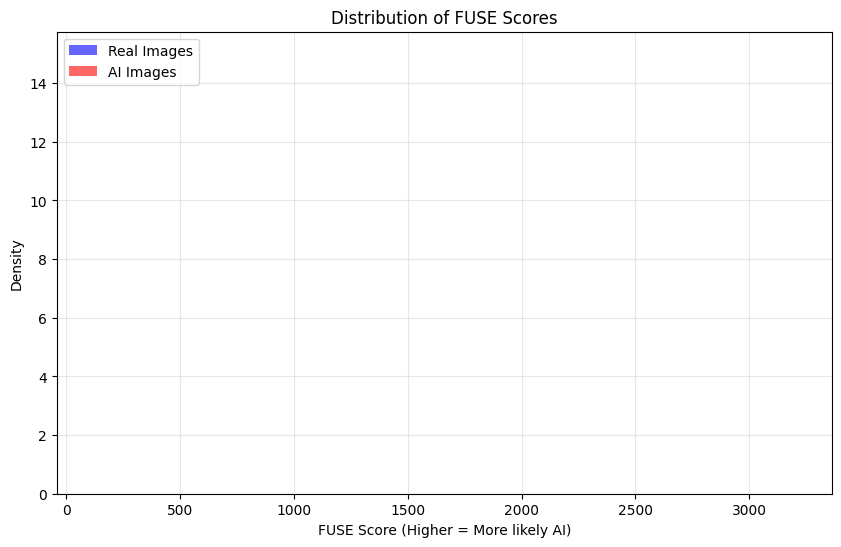

In [ ]:
if not df_results.empty:
    plt.figure(figsize=(10, 6))
    
    # Debug: Check values
    print("Scores Summary:")
    print(df_results['fuse_score'].describe())
    
    # Clean Infinite Values
    df_clean = df_results.replace([np.inf, -np.inf], np.nan).dropna(subset=['fuse_score'])
    print(f"Valid samples after cleaning Inf: {len(df_clean)}")
    
    real_scores = df_clean[df_clean['label'] == 0]['fuse_score']
    fake_scores = df_clean[df_clean['label'] == 1]['fuse_score']
    
    if len(real_scores) > 0 and len(fake_scores) > 0:
        plt.hist(real_scores, bins=20, alpha=0.6, label='Real Images', color='blue', density=True)
        plt.hist(fake_scores, bins=20, alpha=0.6, label='AI Images', color='red', density=True)
        
        plt.title('Distribution of FUSE Scores')
        plt.xlabel('FUSE Score')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("Data exists but is not suitable for plotting (maybe all values are NaN/Inf?)")
        if len(real_scores) == 0:
            print("Real scores are all invalid.")
        if len(fake_scores) == 0:
            print("Fake scores are all invalid.")
else:
    print("DataFrame is empty. Cannot plot.")

## 6. Calculate Performance Metrics (ROC-AUC)

Important for quantitative analysis in your thesis.


ROC-AUC Score: 1.0000
Optimal Threshold: 3207.5106
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000


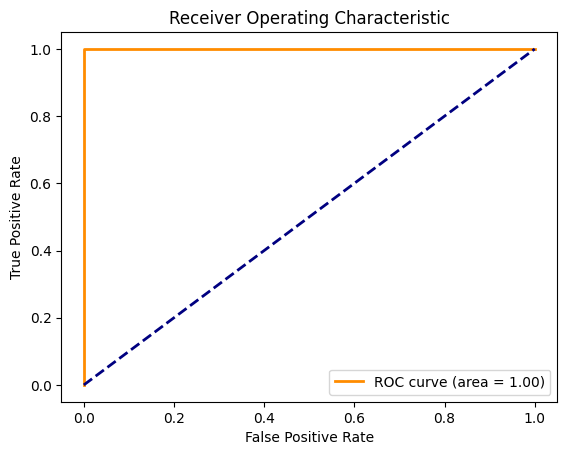

In [6]:
if not df_results.empty:
    y_true = df_results['label']
    y_scores = df_results['fuse_score']
    
    # 1. AUC Score
    roc_auc = 0.5
    try:
        fpr, tpr, thresholds = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        print(f"\nROC-AUC Score: {roc_auc:.4f}")
    except Exception as e:
        print(f"Metrics Error (Needs both classes): {e}")

    # 2. Find Optimal Threshold (Youden's J statistic)
    if roc_auc > 0.5:
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]
        print(f"Optimal Threshold: {optimal_threshold:.4f}")
        
        # 3. Accuracy at Threshold
        y_pred = (y_scores >= optimal_threshold).astype(int)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        
        print(f"Accuracy: {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        
        # Plot ROC
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()